# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Macroeconomic Capture & Fiscal Crowding-Out

---
*This notebook studies fiscal crowding-out, the idea that heavier sovereign borrowing pushes up real yields and, through that channel, depresses private capital formation. The data are synthetic and structural: an explicit model in which yields respond to public debt, and private investment responds (with a known coefficient) to yields, to an output-growth accelerator, and to noise. I did not build this to argue crowding-out is real; the effect is planted by construction, so "is it real" is not a question this notebook can answer. What it can show is the **measurement problem**: a latent business cycle lifts both yields and investment at the same time, so the naive correlation between them is not wrong because it was computed badly — it is answering a different question, one about co-movement, not about the structural channel. That is why only a model that holds the cycle constant recovers the number that was actually planted. The deliverable here is the method, not a claim about any real economy.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette("flare")

In [2]:
# Synthetic data loading
df = pd.read_csv('../data/macroeconomic_budget_synthetic.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.head()

,Government_Spending,Tax_Revenue,Sovereign_Debt_Outstanding,Sovereign_Yield_10Y,Output_Growth_Pct,Private_Capital_Formation
Date,,,,,,
2000-03-31,1010.950062,844.681796,166.268266,0.025620,0.000000,2414.776133
2000-06-30,1012.168421,852.243066,326.193621,0.033536,1.497485,2446.503385
2000-09-30,1030.295002,865.420342,491.068281,0.016874,-2.661313,2413.462498
2000-12-31,1025.568193,883.544243,633.092232,0.029027,3.301084,2511.919476
2001-03-31,1022.991014,861.822935,794.260312,0.037015,3.282112,2501.046503


### 1. The budget constraint: deficit plus the cost of past debt
I isolate the primary deficit and the debt service cost ($r B_{t-1}$) to trace the trajectory of government issuance.

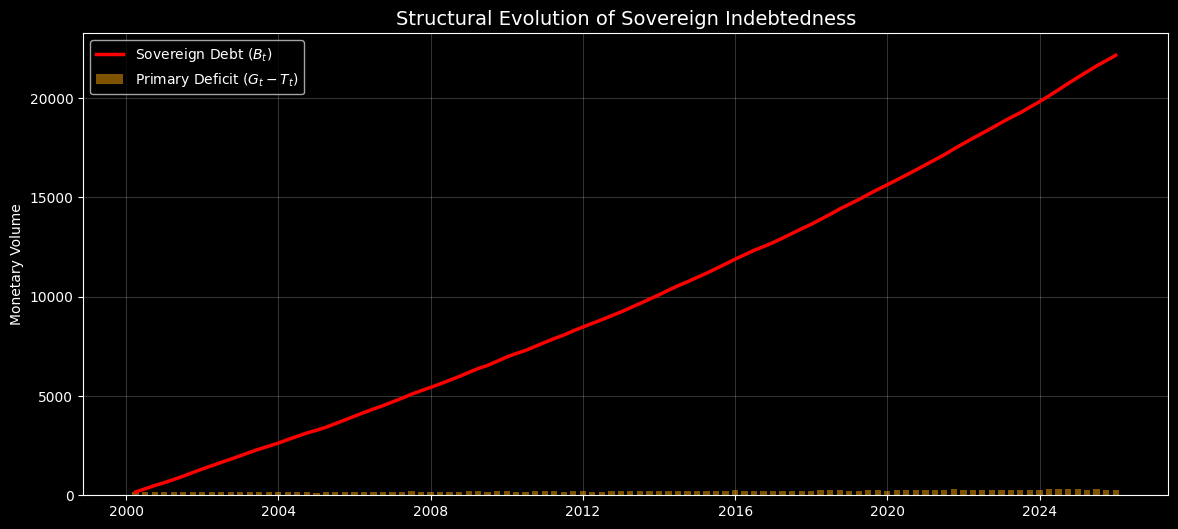

In [3]:
df['Primary_Deficit'] = df['Government_Spending'] - df['Tax_Revenue']
df['Debt_Service_Cost'] = df['Sovereign_Debt_Outstanding'].shift(1) * (df['Sovereign_Yield_10Y'] / 4) # Quarterly annualized
df['Total_Deficit'] = df['Primary_Deficit'] + df['Debt_Service_Cost']
df['Debt_Service_Cost'].fillna(0, inplace=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Sovereign_Debt_Outstanding'], color='red', linewidth=2.5, label='Sovereign Debt ($B_t$)')
ax.bar(df.index, df['Primary_Deficit'], color='orange', alpha=0.5, width=60, label='Primary Deficit ($G_t - T_t$)')

ax.set_title("Structural Evolution of Sovereign Indebtedness", fontsize=14)
ax.set_ylabel("Monetary Volume")
ax.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

### 2. The naive view of crowding-out — and why it misleads
The intuitive test is a simple correlation: when the sovereign yield rises, does private capital formation fall? It does. And yet that correlation is not the crowding-out effect: a latent business cycle lifts the yield (through the monetary-policy reaction) and investment (through the output-growth accelerator) at the same time, so boom-time co-movement quietly eats into the structural channel I actually want to measure. I look at the naive picture first, because that is the number everyone reaches for, and then correct it.

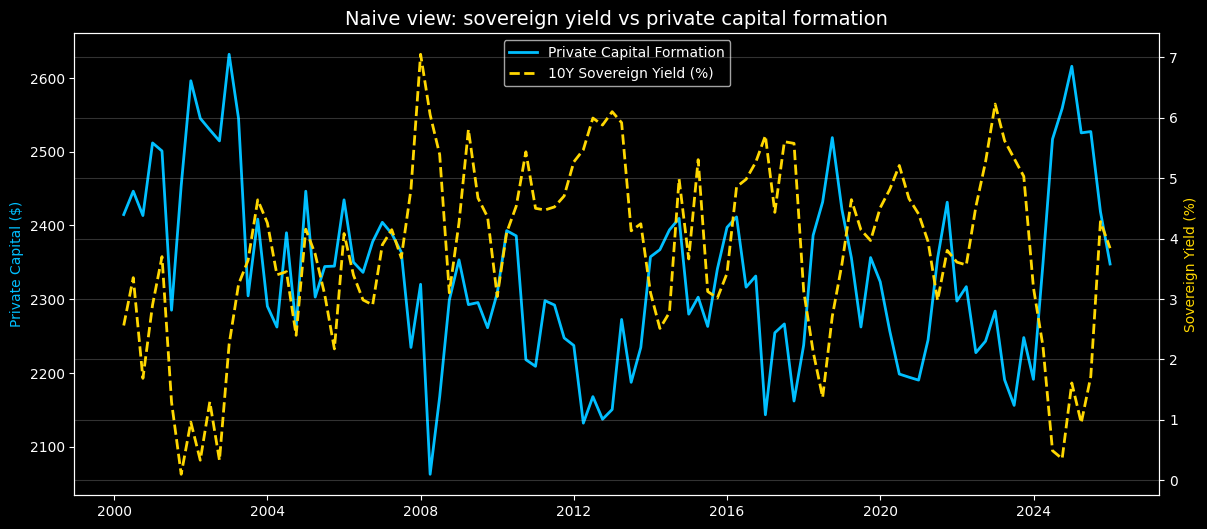

Naive correlation(yield, private)   : -0.704  (p = 7.39e-17)
Naive slope (private per +1pp yield) : -55.6
This simple slope is BIASED: it conflates the crowding-out channel with the business
cycle, which pushes yields and investment up together. It is not yet a causal estimate.


In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(df.index, df['Private_Capital_Formation'], color='deepskyblue', linewidth=2, label='Private Capital Formation')
ax2.plot(df.index, df['Sovereign_Yield_10Y'] * 100, color='gold', linewidth=2, linestyle='--', label='10Y Sovereign Yield (%)')
ax1.set_title("Naive view: sovereign yield vs private capital formation", fontsize=14)
ax1.set_ylabel("Private Capital ($)", color='deepskyblue')
ax2.set_ylabel("Sovereign Yield (%)", color='gold')
l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper center')
plt.grid(True, alpha=0.2); plt.show()

yld_pct = df['Sovereign_Yield_10Y'] * 100
corr, pval = pearsonr(yld_pct, df['Private_Capital_Formation'])
naive_slope = np.polyfit(yld_pct, df['Private_Capital_Formation'], 1)[0]
print(f"Naive correlation(yield, private)   : {corr:.3f}  (p = {pval:.2e})")
print(f"Naive slope (private per +1pp yield) : {naive_slope:.1f}")
print("This simple slope is BIASED: it conflates the crowding-out channel with the business")
print("cycle, which pushes yields and investment up together. It is not yet a causal estimate.")

### 3. Isolating the structural effect — controlling for the cycle
To recover the crowding-out coefficient, I regress private capital formation on the yield and on output growth, an observable proxy for the cycle. Hold that confounder constant and the yield coefficient isolates the structural channel — the number the naive correlation was hiding. Because the data are synthetic I know the planted value, −75 per percentage point, and can simply check the estimate against it rather than argue about whether it is plausible.

In [5]:
X = sm.add_constant(pd.DataFrame({
    'Yield_pct': df['Sovereign_Yield_10Y'] * 100,
    'Output_Growth_Pct': df['Output_Growth_Pct'],
}))
model = sm.OLS(df['Private_Capital_Formation'], X).fit()
print(model.summary().tables[1])
print(f"\nNaive (uncontrolled) yield slope     : {naive_slope:7.1f}")
print(f"Controlled yield slope (crowding-out): {model.params['Yield_pct']:7.1f}   [planted truth: -75.0]")
print(f"Output-growth (accelerator) slope    : {model.params['Output_Growth_Pct']:7.1f}   [planted truth: +40.0]")

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2592.7006      9.900    261.900      0.000    2573.062    2612.339
Yield_pct           -73.0927      2.505    -29.176      0.000     -78.062     -68.123
Output_Growth_Pct    40.8226      1.905     21.434      0.000      37.044      44.601

Naive (uncontrolled) yield slope     :   -55.6
Controlled yield slope (crowding-out):   -73.1   [planted truth: -75.0]
Output-growth (accelerator) slope    :    40.8   [planted truth: +40.0]


### Conclusion — what this measures, and what it doesn't
The naive yield–investment correlation understates crowding-out, not because it is measured carelessly, but because a latent business cycle lifts yields and investment together, so part of the true structural drag gets absorbed into that shared boom. That is the confound this notebook corrects for: hold output growth constant and the yield coefficient recovers the number actually planted in the generator, roughly −75 per percentage point. The gap between −55.6 and −73.1 is the whole lesson.

Two honesties are worth keeping in view. The relationship is **synthetic by construction**: I am not claiming crowding-out is empirically real, only showing how to measure such an effect without being fooled by a confounder that moves in the same direction as the thing you are trying to isolate. And even granting that, one regression on synthetic data licenses no policy claim about any real economy. What survives is a habit: the next time a raw correlation between a policy variable and an outcome shows up on a slide, ask what shared driver could be lifting both — and don't report the correlation as the causal number until something has actually been held constant.